#Performing Binary Classifier on Two species of Turkish Rice

In [1]:
import keras
import numpy as np
import pandas as pd
import plotly.express as px
import ml_edu.experiment
import ml_edu.results

pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

In [2]:
rice_data = pd.read_csv("Rice_Cammeo_Osmancik.csv")
rice_data.columns
rice_data

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.6,229.7,85.1,0.9,15617,0.6,Cammeo
1,14656,494.3,206.0,91.7,0.9,15072,0.6,Cammeo
2,14634,501.1,214.1,87.8,0.9,14954,0.7,Cammeo
3,13176,458.3,193.3,87.4,0.9,13368,0.6,Cammeo
4,14688,507.2,211.7,89.3,0.9,15262,0.6,Cammeo
...,...,...,...,...,...,...,...,...
3805,11441,415.9,170.5,85.8,0.9,11628,0.7,Osmancik
3806,11625,421.4,167.7,89.5,0.8,11904,0.7,Osmancik
3807,12437,442.5,183.6,86.8,0.9,12645,0.6,Osmancik
3808,9882,392.3,161.2,78.2,0.9,10097,0.7,Osmancik


In [3]:
# show descriptive statistics on the data
rice_data.describe()
#rice_data.select_dtypes(include=['number']).columns

#for i in rice_data.columns:
    #if i not in rice_data.select_dtypes(include=['number']).columns:
        #print(i)
#rice_data.select_dtypes(include=['object']).columns


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0
mean,12667.7,454.2,188.8,86.3,0.9,12952.5,0.7
std,1732.4,35.6,17.4,5.7,0.0,1777.0,0.1
min,7551.0,359.1,145.3,59.5,0.8,7723.0,0.5
25%,11370.5,426.1,174.4,82.7,0.9,11626.2,0.6
50%,12421.5,448.9,185.8,86.4,0.9,12706.5,0.6
75%,13950.0,483.7,203.6,90.1,0.9,14284.0,0.7
max,18913.0,548.4,239.0,107.5,0.9,19099.0,0.9


In [4]:
# 1. What is the min and max lengths of the Major_Axis_Length in pixels
print(f'The minimum length of the "Major_Axis_Length" column is {rice_data['Major_Axis_Length'].min():.1f}px\n'
      f'And the maximum length of the "Major_Axis_Length"  is {rice_data['Major_Axis_Length'].max():.1f}\n ')

# 2. what is the range of areas between the smallest and largest rice grain
print(f'The smallest rice grain has an Area of {rice_data['Area'].min():.1f}px\n'
      f'And the largest rice grain has an Area of {rice_data['Area'].max():.1f}px\n ')

# 3. How many std is the largest Rice grain's perimeter away from its mean
smallest_grain_perimeter = rice_data['Perimeter'].min()
largest_grain_perimeter = rice_data['Perimeter'].max()
mean_perimeter = rice_data['Perimeter'].mean()
std_perimeter = rice_data['Perimeter'].std()
z_score_perimeter = (largest_grain_perimeter - mean_perimeter)/std_perimeter
print(f'The Largest rice grain perimeter is {z_score_perimeter:.1f}px away from the mean perimeter.')


The minimum length of the "Major_Axis_Length" column is 145.3px
And the maximum length of the "Major_Axis_Length"  is 239.0
 
The smallest rice grain has an Area of 7551.0px
And the largest rice grain has an Area of 18913.0px
 
The Largest rice grain perimeter is 2.6px away from the mean perimeter.


In [5]:
# Create five 2D plots of the features against each other, color-coded by class.

for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),] :

    px.scatter(rice_data,x=x_axis_data,y=y_axis_data,color="Class",width=800,height=300).show()

In [6]:
#@title Plot three features in 3D by entering their names and running this cell

x_axis_data = 'Major_Axis_Length'  
y_axis_data = 'Eccentricity'  
z_axis_data = 'Area'  

px.scatter_3d(
    rice_data,
    x=x_axis_data,
    y=y_axis_data,
    z=z_axis_data,
    color="Class",
    height=300,
    width=800,
    

).show()


Been tasked to train a Binary classifier Model on the three features plotted above
First,I have to make sure that values in each feature I am gonna train with all span across the same range so as not to have Weights of extremely low or high values to combine with the features to make the model more accurate.

In that case, I am using the z-score across all numerical features to ensure values in all features have the same range.
z-score = (Observed_vals - Estimated_mean)/ standard_deviation

In [7]:
# set up params
feature_mean = rice_data.mean(numeric_only=True)
feature_std = rice_data.std(numeric_only=True)
num_features = rice_data.select_dtypes(include='number').columns
normalized_features = (rice_data[num_features] - feature_mean)/feature_std
normalized_features
feature_mean

Area                12667.7
Perimeter             454.2
Major_Axis_Length     188.8
Minor_Axis_Length      86.3
Eccentricity            0.9
Convex_Area         12952.5
Extent                  0.7
dtype: float64

In [8]:
# copy the 'Class' from old frame to normalized frame
normalized_features['Class'] = rice_data['Class']
normalized_features

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,1.5,2.0,2.3,-0.2,2.0,1.5,-1.2,Cammeo
1,1.1,1.1,1.0,0.9,0.4,1.2,-0.6,Cammeo
2,1.1,1.3,1.5,0.3,1.2,1.1,0.4,Cammeo
3,0.3,0.1,0.3,0.2,0.2,0.2,-0.3,Cammeo
4,1.2,1.5,1.3,0.5,1.0,1.3,-0.2,Cammeo
...,...,...,...,...,...,...,...,...
3805,-0.7,-1.1,-1.0,-0.1,-1.1,-0.7,0.2,Osmancik
3806,-0.6,-0.9,-1.2,0.5,-2.0,-0.6,0.4,Osmancik
3807,-0.1,-0.3,-0.3,0.1,-0.3,-0.2,-0.5,Osmancik
3808,-1.6,-1.7,-1.6,-1.4,-0.6,-1.6,-0.0,Osmancik


Set up the random seeds for experiment reproducibility

In [9]:
keras.utils.set_random_seed(42)

I label the "Osmancik" as 1 and label the "Cammeo" as 0

In [10]:
normalized_features['Class_Bool'] = ( normalized_features['Class'] == 'Osmancik' ).astype(int)
normalized_features.sample(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,-0.1,0.1,-0.1,0.2,-0.1,-0.0,-1.0,Cammeo,0
3185,-0.1,-0.5,-0.5,0.4,-0.8,-0.2,-0.3,Osmancik,1
3698,0.1,-0.1,-0.4,0.9,-1.1,0.1,-0.2,Osmancik,1
897,0.2,0.5,0.8,-0.5,1.2,0.2,1.5,Cammeo,0
3245,-1.3,-1.3,-0.9,-1.6,0.5,-1.4,-1.1,Osmancik,1
478,0.2,0.2,0.4,-0.0,0.5,0.2,1.7,Cammeo,0
1731,-0.4,-0.8,-0.8,0.3,-1.0,-0.5,-0.4,Osmancik,1
1025,0.6,0.7,0.6,0.3,0.5,0.6,-0.5,Cammeo,0
429,1.2,1.2,1.4,0.6,1.0,1.2,1.8,Cammeo,0
1330,-0.4,-0.0,0.4,-1.3,1.4,-0.5,-0.1,Cammeo,0


Let's split the data to train, validation, test factions.
we first randomize the dataset, take up to the 80th percentile for the train,
80th-90th percentile for the validation and 90th to end for the test.

In [11]:
shuffled_data = normalized_features.sample(frac=1,random_state=100)
percentile_80th = round(len(normalized_features) * 0.8)
percentile_90th = percentile_80th + round(len(normalized_features) * 0.1)

train_data = normalized_features.iloc[0:percentile_80th]
validation_data = normalized_features.iloc[percentile_80th:percentile_90th]
test_data = normalized_features.iloc[percentile_90th:]

test_data.head(10)

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
3429,-0.4,-0.4,-0.3,-0.4,0.1,-0.5,-1.0,Osmancik,1
3430,0.3,-0.2,-0.8,2.1,-2.8,0.3,-0.0,Osmancik,1
3431,-0.9,-1.3,-1.3,-0.0,-1.5,-0.9,-0.5,Osmancik,1
3432,-0.3,-0.2,0.1,-0.8,0.8,-0.3,-1.2,Osmancik,1
3433,0.5,0.3,0.0,1.1,-0.7,0.5,-0.6,Osmancik,1
3434,0.3,0.2,0.0,0.8,-0.5,0.3,-0.8,Osmancik,1
3435,-1.2,-0.8,-0.5,-1.7,0.9,-1.2,0.1,Osmancik,1
3436,-0.4,-0.4,-0.5,-0.1,-0.3,-0.4,-0.8,Osmancik,1
3437,-0.3,-0.4,-0.3,-0.2,0.0,-0.4,-0.5,Osmancik,1
3438,-0.4,-0.5,-0.8,0.5,-1.3,-0.4,-0.6,Osmancik,1


let's create the labels and training features

In [12]:
label_cols = ['Class','Class_Bool']

train_features = train_data.drop(columns=label_cols)
train_labels = train_data['Class_Bool'].to_numpy()
validation_features = validation_data.drop(columns=label_cols)
validation_labels = validation_data["Class_Bool"].to_numpy()
test_features = test_data.drop(columns=label_cols)
test_labels = test_data["Class_Bool"].to_numpy()

Let's Train our model 
Input features:
1. Eccentricity
2. Major_Axis_Length
3. Area

In [13]:
# Declare input features first
Input_features = ["Eccentricity","Major_Axis_Length","Area"]

Omo, Na hardest part be this: Create functions that build and train the model 
1. create_model(inputs, learning_rate, metrics), which builds our model architecture
2. train_model(model,dataset,epochs,label_name,batch_size,shuffle), uses input features and labels to train the model.

We also define two helpful data structures: `ExperimentSettings` and `Experiment`. We use these simple classes to keep track of our experiments, allowing us to know what hyperparameters were used and what the results were. In `ExperimentSettings`, we store all values describing an experiment (i.e., hyperparameters). Then, we store the results of a training run (i.e., the model and the training metrics) into an `Experiment` instance, along with the `ExperimentSettings` used for that experiment.

In [16]:
def create_model(
    settings:ml_edu.experiment.ExperimentSettings,
    metrics:list[keras.metrics.Metric]
)-> keras.Model:

    """Create and compile a simple Classification Model"""

    model_inputs = [keras.Input(name=feature,shape=(1,)) for feature in settings.input_features]

    # Use a concatenate layer to assemble all inputs into a single tensor which will be passed as an input to the dense layer
    concat_inputs = keras.layers.Concatenate()(model_inputs)
    model_output = keras.layers.Dense(units=1,name='dense_layer',activation=keras.activations.sigmoid)(concat_inputs)

    model = keras.Model(inputs=model_inputs,outputs=model_output)
    # call the keras.compile() method to complile the layers in a form keras can execute. we use a different loss function here for classification than regression
    model.compile(
        optimizer=keras.optimizers.RMSprop(settings.learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=metrics,
    )
    return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    labels: np.ndarray,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
    '''Feed dataset to model to train it'''

# the x parameter of keras.Model.fit can be a list of arrays where each array can rep a feature

    features = {
        feature_name: np.array(dataset[feature_name])
        for feature_name in settings.input_features
    }

    history = model.fit(
        x=features,
        y=labels,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs
    )
    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history),
        )

print("Architecture created.")


Architecture created.


Invoke fucnctions above by initializing  hyperparams
Classification threshold is set at .35. Try playing with the threshold, then the learning rate, to see what changes.

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2910 - auc: 0.0794 - loss: 1.1538 - precision: 0.3510 - recall: 0.6171
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3041 - auc: 0.0905 - loss: 1.1005 - precision: 0.3611 - recall: 0.6446
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3169 - auc: 0.1031 - loss: 1.0519 - precision: 0.3706 - recall: 0.6707
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3340 - auc: 0.1198 - loss: 1.0049 - precision: 0.3829 - recall: 0.7059
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3533 - auc: 0.1415 - loss: 0.9596 - precision: 0.3963 - recall: 0.7454
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3678 - auc: 0.1696 - loss: 0.9161 - precision: 0.4059 - recall: 0.7743
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3868 - auc: 0.2054 - loss: 0.8742 - precision: 0.4183 - recall: 0.8138
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc

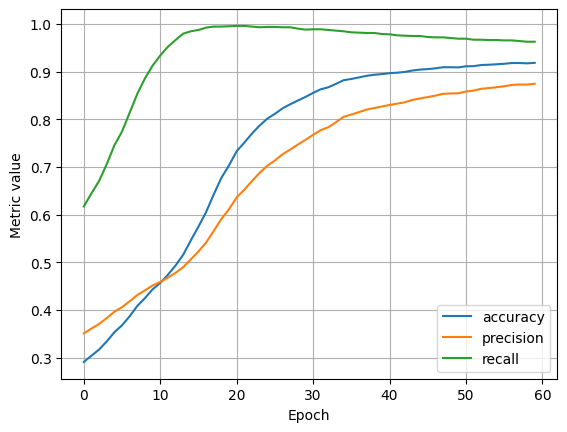

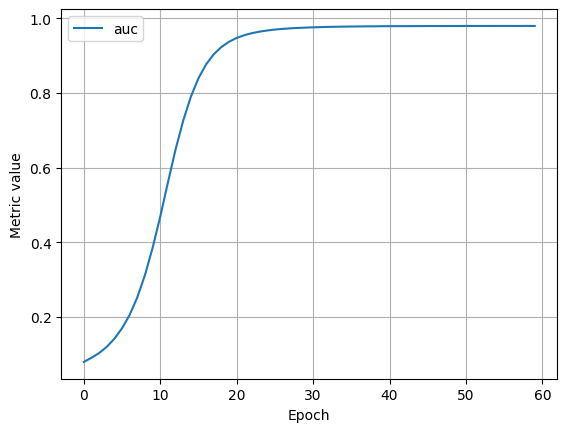

In [23]:
# Let's define our first experiment settings
settings = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.3,
    input_features=Input_features,
)

metrics = [ keras.metrics.BinaryAccuracy(
    name="accuracy",threshold=settings.classification_threshold
),
keras.metrics.Precision(
    name='precision',thresholds=settings.classification_threshold
),
keras.metrics.Recall(
    name='recall',thresholds=settings.classification_threshold
),
keras.metrics.AUC(
    name="auc",
    num_thresholds=100
)
]

# build model
model = create_model(settings,metrics)

# train model on training set
experiment = train_model('baseline',model,train_features,train_labels,settings)

# plot metrics vs epcohs
ml_edu.results.plot_experiment_metrics(experiment,['accuracy','precision','recall'])
ml_edu.results.plot_experiment_metrics(experiment,['auc'])

Evaluate the model against the validation set

In [25]:
def compare_train_validation(experiment: ml_edu.experiment.Experiment, validation_metrics: dict[str, float]):
    for metric, validation_value in validation_metrics.items():
        print(f'Train {metric}:{experiment.get_final_metric_value(metric):.4f}')
        print(f'Validation {metric}: {validation_value:.4f}\n')


# Evaluate validation metrics
validation_metrics = experiment.evaluate(validation_features,validation_labels)
compare_train_validation(experiment,validation_metrics)

Train accuracy:0.9183
Validation accuracy: 0.9475

Train auc:0.9796
Validation auc: 0.0000

Train loss:0.1888
Validation loss: 0.2383

Train precision:0.8744
Validation precision: 1.0000

Train recall:0.9626
Validation recall: 0.9475



In [28]:
# Let's train the data using all the features,excluding the label "Class"
all_features = rice_data.drop(columns='Class').columns


Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5000 - auc: 0.5054 - loss: 0.8168 - precision: 0.4643 - recall: 0.4866
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5502 - auc: 0.5712 - loss: 0.7560 - precision: 0.5162 - recall: 0.5268
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5938 - auc: 0.6292 - loss: 0.7034 - precision: 0.5641 - recall: 0.5585
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6329 - auc: 0.6832 - loss: 0.6548 - precision: 0.6079 - recall: 0.5938
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6696 - auc: 0.7318 - loss: 0.6100 - precision: 0.6501 - recall: 0.6276
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7047 - auc: 0.7749 - loss: 0.5686 - precision: 0.6913 - recall: 0.6601
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7359 - auc: 0.8121 - loss: 0.5306 - precision: 0.7255 - recall: 0.6953
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc

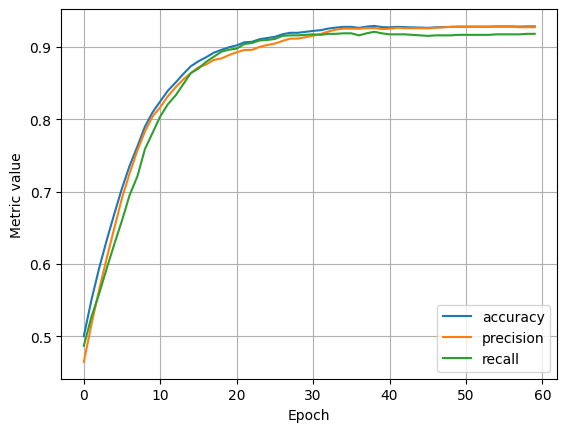

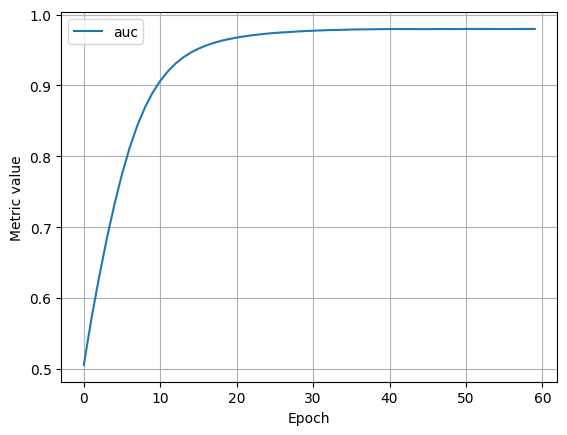

In [30]:
# Let's train on all features


settings_all_features = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.5,
    input_features=all_features,
)


metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy',
        threshold=settings_all_features.classification_threshold,
    ),
    keras.metrics.Precision(
        name='precision',
        thresholds=settings_all_features.classification_threshold,
    ),
    keras.metrics.Recall(
        name='recall', thresholds=settings_all_features.classification_threshold
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),
]

# Establish the model's topography.
model_all_features = create_model(settings_all_features, metrics)

# Train the model on the training set.
experiment_all_features = train_model(
    'all features',
    model_all_features,
    train_features,
    train_labels,
    settings_all_features,
)

# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(
    experiment_all_features, ['accuracy', 'precision', 'recall']
)
ml_edu.results.plot_experiment_metrics(experiment_all_features, ['auc'])

Evaluating all features model against validation set

In [31]:
validation_metrics_all_features = experiment_all_features.evaluate(
    validation_features,
    validation_labels,
)
compare_train_validation(experiment_all_features, validation_metrics_all_features)

Train accuracy:0.9285
Validation accuracy: 0.9029

Train auc:0.9797
Validation auc: 0.0000

Train loss:0.1797
Validation loss: 0.2282

Train precision:0.9274
Validation precision: 1.0000

Train recall:0.9182
Validation recall: 0.9029



Let's compare our two models

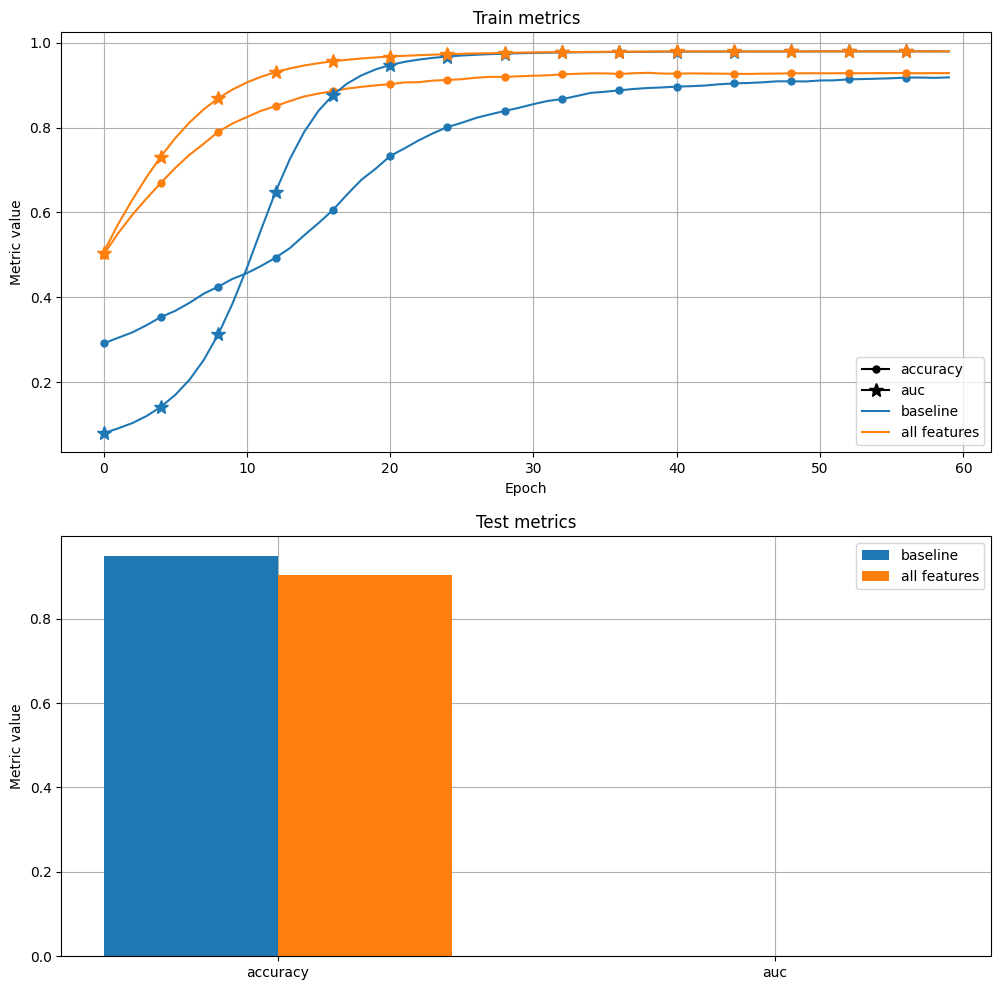

In [32]:
ml_edu.results.compare_experiment([experiment, experiment_all_features],
                                  ['accuracy', 'auc'],
                                  validation_features, validation_labels)

computing final test metrics

In [33]:
test_metrics_all_features = experiment_all_features.evaluate(
    test_features,
    test_labels,
)
for metric, test_value in test_metrics_all_features.items():
  print(f'Test {metric}:  {test_value:.4f}')

Test accuracy:  0.8871
Test auc:  0.0000
Test loss:  0.2529
Test precision:  1.0000
Test recall:  0.8871
